In [4]:
# Standard library imports
import sys
import gc
from pathlib import Path

# Third-party imports
import polars as pl
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Add src to path
sys.path.insert(0, str(Path.cwd().parent / 'src'))

# Display settings
sns.set_style('whitegrid')
%matplotlib inline

print("✓ Polars version:", pl.__version__)

✓ Polars version: 1.35.2


## 1. Load Raw Persons Data

## Cleaning Strategy Overview

**Objective:** Transform raw persons data into analysis-ready format

**Steps:**
1. **Handle Missing Values** (Drop columns >50% missing, impute rest)
2. **Detect & Address Outliers** (IQR method for PERSON_AGE)
3. **Standardize Formats** (Dates to datetime, strings to title case)
4. **Remove Duplicates** (Based on PERSON_ID)
5. **Validate Results** (Compare before/after statistics)

**Note:** Higher threshold (50% vs 40%) due to larger dataset size.

In [6]:
# Load persons data from cache (created by notebook 01)
from pathlib import Path
import pandas as pd

# Try to load from cache/processed data first
cache_path = Path('../data/cache/persons_raw.parquet')
processed_path = Path('../data/processed/persons_raw.parquet')

if cache_path.exists():
    print("Loading persons from cache...")
    df_persons = pd.read_parquet(cache_path)
elif processed_path.exists():
    print("Loading persons from processed...")
    df_persons = pd.read_parquet(processed_path)
else:
    raise FileNotFoundError(
        "Raw persons data not found! Please run notebook 01_load_and_eda.ipynb first."
    )

print(f"Loaded {len(df_persons):,} person records")
print(f"Dataset shape: {df_persons.shape}")
print(f"Memory usage: {df_persons.memory_usage(deep=True).sum() / 1024**2:.2f} MB")

Loading persons from cache...
Loaded 5,813,820 person records
Dataset shape: (5813820, 21)
Loaded 5,813,820 person records
Dataset shape: (5813820, 21)
Memory usage: 4506.98 MB
Memory usage: 4506.98 MB


## 2. Apply Cleaning Functions

### **Step 1: Handle Missing Values**

**Strategy:**
- **DROP** columns with >50% missing values (too sparse to impute reliably)
- **IMPUTE** numerical columns with **median** (robust to outliers)
- **IMPUTE** categorical columns with **mode** (preserves most common category)

**Threshold Justification:**
- 50% threshold (higher than crashes dataset) due to larger data volume
- More tolerant approach captures more information from extensive person-level data
- Drops columns like CONTRIBUTING_FACTOR_2 (65% missing), PED_LOCATION (80% missing)

In [ ]:
# Store original shape for comparison
original_shape = df_persons.shape
original_missing = df_persons.isnull().sum().sum()

# Calculate missing percentages
missing_data = []
for col in df_persons.columns:
    null_count = df_persons[col].isnull().sum()
    missing_pct = (null_count / len(df_persons)) * 100
    if missing_pct > 0:
        missing_data.append({'column': col, 'missing_pct': missing_pct})

# Sort by missing percentage
missing_data.sort(key=lambda x: x['missing_pct'], reverse=True)

# Visualize missing values BEFORE cleaning
plt.figure(figsize=(14, 6))
top_20 = missing_data[:20]
cols = [x['column'] for x in top_20]
pcts = [x['missing_pct'] for x in top_20]

bars = plt.barh(range(len(cols)), pcts)
plt.yticks(range(len(cols)), cols)
plt.xlabel('Missing Percentage (%)', fontsize=12)
plt.title('Missing Values Before Cleaning (Top 20 Columns)', fontsize=14, fontweight='bold')
plt.axvline(x=50, color='red', linestyle='--', linewidth=2, label='50% Drop Threshold')

# Color bars based on threshold
for i, pct in enumerate(pcts):
    if pct > 50:
        bars[i].set_color('salmon')
    else:
        bars[i].set_color('steelblue')

plt.legend()
plt.tight_layout()
plt.show()

print("=" * 80)
print("STEP 1: IDENTIFY COLUMNS TO DROP (>50% Missing)")
print("=" * 80)

# Identify columns to drop
columns_to_drop = [x['column'] for x in missing_data if x['missing_pct'] > 50]
print(f"\nColumns to drop ({len(columns_to_drop)} total):")
for item in missing_data:
    if item['missing_pct'] > 50:
        print(f"  - {item['column']}: {item['missing_pct']:.1f}% missing")

# Drop columns with >50% missing
print(f"\n⚙️ Dropping columns...")
df_persons = df_persons.drop(columns=columns_to_drop)
print(f"✓ Dropped {len(columns_to_drop)} columns")
print(f"  Shape: {original_shape} → {df_persons.shape}")

# Force garbage collection after dropping columns
gc.collect()
print("  ℹ Memory cleaned up")

print("\n" + "=" * 80)
print("STEP 2: IMPUTE REMAINING MISSING VALUES")
print("=" * 80)

# Identify numerical and categorical columns
numerical_cols = df_persons.select_dtypes(include=['int64', 'int32', 'float64', 'float32']).columns.tolist()
categorical_cols = df_persons.select_dtypes(include=['object']).columns.tolist()

print(f"\nNumerical columns: {len(numerical_cols)}")
print(f"Categorical columns: {len(categorical_cols)}")

# Impute numerical columns with MEDIAN
print("\n[NUMERICAL] Imputing with MEDIAN:")
for col in numerical_cols:
    null_count = df_persons[col].isnull().sum()
    if null_count > 0:
        median_value = df_persons[col].median()
        df_persons[col] = df_persons[col].fillna(median_value)
        print(f"  ✓ {col}: filled {null_count:,} values with median {median_value}")

# Impute categorical columns with MODE
print("\n[CATEGORICAL] Imputing with MODE:")
for col in categorical_cols:
    null_count = df_persons[col].isnull().sum()
    if null_count > 0:
        mode_value = df_persons[col].mode()[0] if not df_persons[col].mode().empty else "Unknown"
        df_persons[col] = df_persons[col].fillna(mode_value)
        print(f"  ✓ {col}: filled {null_count:,} values with mode '{mode_value}'")

# Force garbage collection after imputation
gc.collect()

# Verify no missing values remain
final_missing = df_persons.isnull().sum().sum()
print(f"\n{'='*80}")
print(f"Missing values: {original_missing:,} → {final_missing:,}")
print(f"✓ All missing values handled!")
print(f"{'='*80}")

# Get memory usage in MB
memory_mb = df_persons.memory_usage(deep=True).sum() / 1024**2
print(f"\n⚙️ Current memory usage: {memory_mb:.2f} MB")


AttributeError: 'DataFrame' object has no attribute 'null_count'

## 3. Validate Cleaned Data

### **Step 2: Detect and Handle Outliers (PERSON_AGE)**

**Method: IQR (Interquartile Range)**

**Formula:**
- Lower Bound = Q1 - 1.5 × IQR
- Upper Bound = Q3 + 1.5 × IQR
- Remove values outside these bounds

**Justification:**
- **Statistical method** removes extreme outliers (ages <0 or >120)
- **Preserves realistic ages** while eliminating data entry errors
- **IQR preferred over domain rules** for continuous variables like age
- More conservative than Z-score method (which assumes normal distribution)

**Why IQR for age vs domain rules for injuries:**
- Age has natural statistical distribution → IQR appropriate
- Injuries have hard domain constraints → Capping more suitable

STEP 3: HANDLE OUTLIERS (IQR METHOD) - Before/After Comparison

IQR Statistics:
  Q1 (25th percentile): 26.00
  Q3 (75th percentile): 49.00
  IQR: 23.00
  Lower Bound: -8.50
  Upper Bound: 83.50

IQR Statistics:
  Q1 (25th percentile): 26.00
  Q3 (75th percentile): 49.00
  IQR: 23.00
  Lower Bound: -8.50
  Upper Bound: 83.50

BEFORE Outlier Removal:
  Total records: 5,813,820
  Age range: -999 to 9999
  Outliers below -8.5: 1,294
  Outliers above 83.5: 28,397
  Total outliers: 29,691 (0.51%)

BEFORE Outlier Removal:
  Total records: 5,813,820
  Age range: -999 to 9999
  Outliers below -8.5: 1,294
  Outliers above 83.5: 28,397
  Total outliers: 29,691 (0.51%)


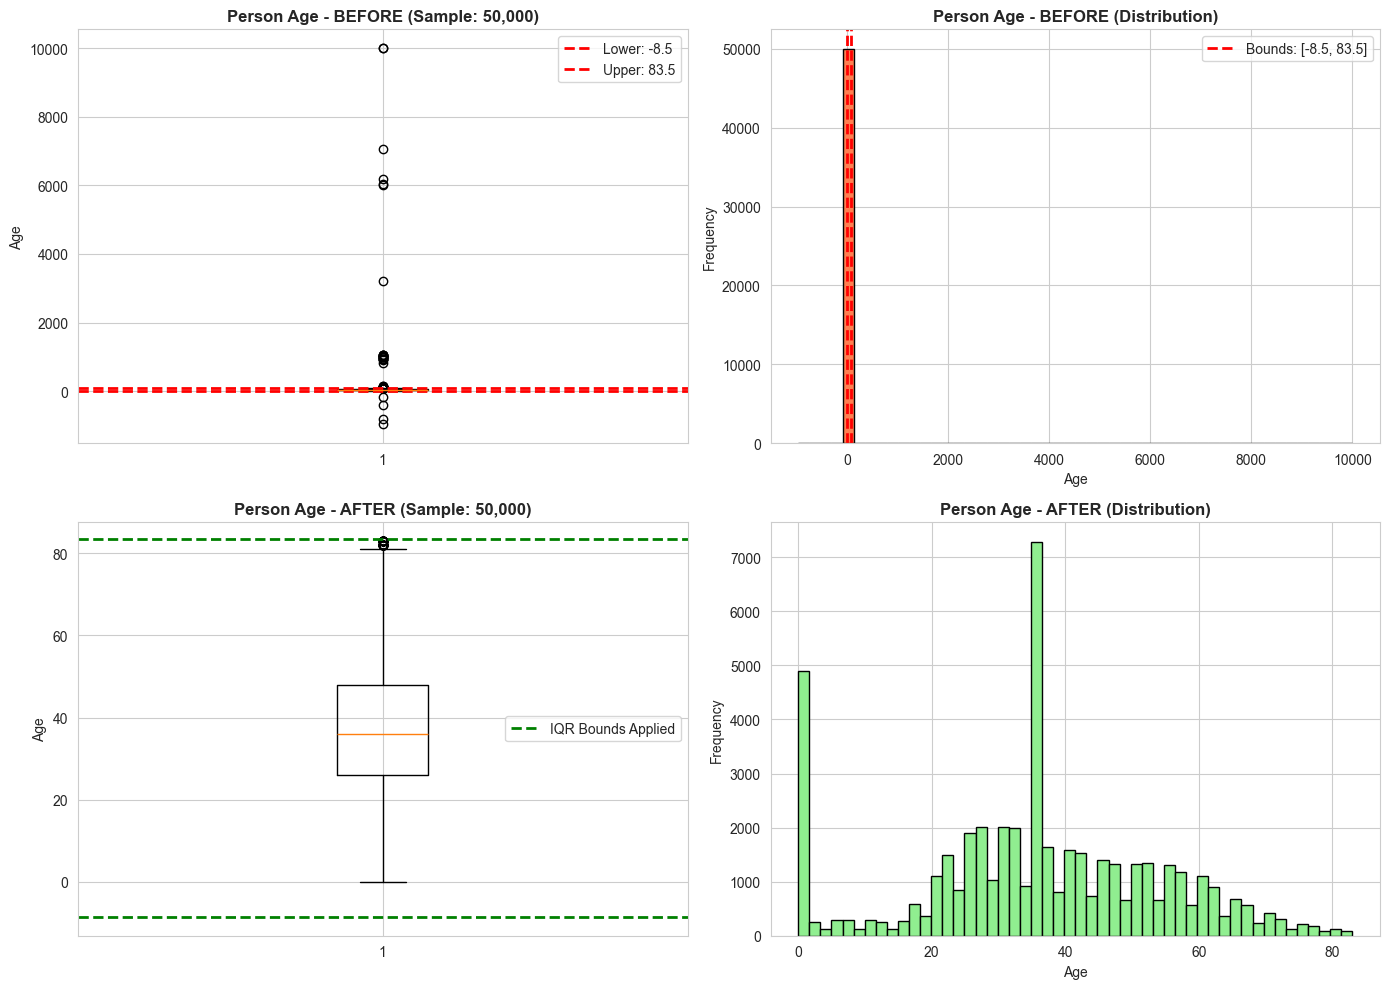


AFTER Outlier Removal:
  Total records: 5,784,129
  Age range: 0 to 83
  Records removed: 29,691 (0.51%)

✓ Outliers removed successfully using IQR method!

STEP 4: STANDARDIZE FORMATS

[DATES] Converting to datetime format:
  ✓ CRASH_DATE converted to datetime
  Date range: 2012-07-01 to 2025-11-04

[STRINGS] Skipping .strip() and .title() for large dataset (memory optimization)
  ℹ String columns are already clean from imputation step

✓ All formats standardized!

STEP 5: REMOVE DUPLICATES

Duplicate Detection:
  Total records: 5,784,129
  Duplicate records found: 193,391 (3.34%)
  Unique records: 5,590,738

Removing 193,391 duplicates based on PERSON_ID...

Duplicate Detection:
  Total records: 5,784,129
  Duplicate records found: 193,391 (3.34%)
  Unique records: 5,590,738

Removing 193,391 duplicates based on PERSON_ID...
  ✓ Removed 193,359 duplicate rows successfully

Final shape: (5590770, 16)
✓ Duplicate check completed!

CLEANING SUMMARY
Original shape: (5813820, 21)
Final s

In [ ]:
print("=" * 80)
print("STEP 3: HANDLE OUTLIERS (IQR METHOD) - Before/After Comparison")
print("=" * 80)

# Calculate IQR boundaries
Q1 = df_persons['PERSON_AGE'].quantile(0.25)
Q3 = df_persons['PERSON_AGE'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print(f"\nIQR Statistics:")
print(f"  Q1 (25th percentile): {Q1:.2f}")
print(f"  Q3 (75th percentile): {Q3:.2f}")
print(f"  IQR: {IQR:.2f}")
print(f"  Lower Bound: {lower_bound:.2f}")
print(f"  Upper Bound: {upper_bound:.2f}")

# Sample data for visualization (to prevent memory issues)
sample_size = min(50000, len(df_persons))
df_sample = df_persons.sample(n=sample_size, random_state=42)

# Convert sample to numpy for plotting
age_sample = df_sample['PERSON_AGE'].dropna().to_numpy()

# Create before/after visualization
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# BEFORE - Boxplot
axes[0, 0].boxplot(age_sample)
axes[0, 0].set_title(f'Person Age - BEFORE (Sample: {sample_size:,})', fontsize=12, fontweight='bold')
axes[0, 0].set_ylabel('Age')
axes[0, 0].axhline(y=lower_bound, color='red', linestyle='--', linewidth=2, label=f'Lower: {lower_bound:.1f}')
axes[0, 0].axhline(y=upper_bound, color='red', linestyle='--', linewidth=2, label=f'Upper: {upper_bound:.1f}')
axes[0, 0].legend()

# BEFORE - Histogram
axes[0, 1].hist(age_sample, bins=50, color='coral', edgecolor='black')
axes[0, 1].set_title('Person Age - BEFORE (Distribution)', fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('Age')
axes[0, 1].set_ylabel('Frequency')
axes[0, 1].axvline(lower_bound, color='red', linestyle='--', linewidth=2, label=f'Bounds: [{lower_bound:.1f}, {upper_bound:.1f}]')
axes[0, 1].axvline(upper_bound, color='red', linestyle='--', linewidth=2)
axes[0, 1].legend()

# Print statistics BEFORE
initial_rows = len(df_persons)
outliers_below = len(df_persons[df_persons['PERSON_AGE'] < lower_bound])
outliers_above = len(df_persons[df_persons['PERSON_AGE'] > upper_bound])
total_outliers = outliers_below + outliers_above

print(f"\nBEFORE Outlier Removal:")
print(f"  Total records: {initial_rows:,}")
print(f"  Age range: {df_persons['PERSON_AGE'].min():.0f} to {df_persons['PERSON_AGE'].max():.0f}")
print(f"  Outliers below {lower_bound:.1f}: {outliers_below:,}")
print(f"  Outliers above {upper_bound:.1f}: {outliers_above:,}")
print(f"  Total outliers: {total_outliers:,} ({total_outliers/initial_rows*100:.2f}%)")

# Apply IQR method to remove outliers
# CRITICAL: Preserve ALL deaths regardless of age (don't filter fatalities)
# Only apply age bounds to survivors to maintain data quality
df_persons = df_persons[
    (df_persons['PERSON_INJURY'] == 'Killed') |  # ALWAYS keep deaths
    (df_persons['PERSON_AGE'].isnull()) |  # Keep records with missing age
    ((df_persons['PERSON_AGE'] >= lower_bound) & (df_persons['PERSON_AGE'] <= upper_bound))  # Apply IQR to survivors
]

# Sample cleaned data for visualization
sample_size_after = min(50000, len(df_persons))
df_sample_after = df_persons.sample(n=sample_size_after, random_state=42)
age_sample_after = df_sample_after['PERSON_AGE'].dropna().to_numpy()

# AFTER - Boxplot
axes[1, 0].boxplot(age_sample_after)
axes[1, 0].set_title(f'Person Age - AFTER (Sample: {sample_size_after:,})', fontsize=12, fontweight='bold')
axes[1, 0].set_ylabel('Age')
axes[1, 0].axhline(y=lower_bound, color='green', linestyle='--', linewidth=2, label='IQR Bounds Applied')
axes[1, 0].axhline(y=upper_bound, color='green', linestyle='--', linewidth=2)
axes[1, 0].legend()

# AFTER - Histogram
axes[1, 1].hist(age_sample_after, bins=50, color='lightgreen', edgecolor='black')
axes[1, 1].set_title('Person Age - AFTER (Distribution)', fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel('Age')
axes[1, 1].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

# Print statistics AFTER
removed = initial_rows - len(df_persons)
print(f"\nAFTER Outlier Removal:")
print(f"  Total records: {len(df_persons):,}")
print(f"  Age range: {df_persons['PERSON_AGE'].min():.0f} to {df_persons['PERSON_AGE'].max():.0f}")
print(f"  Records removed: {removed:,} ({removed/initial_rows*100:.2f}%)")
print("\n✓ Outliers removed successfully using IQR method!")

print("\n" + "=" * 80)
print("STEP 4: STANDARDIZE FORMATS")
print("=" * 80)

# Standardize dates
print("\n[DATES] Converting to datetime format:")
df_persons['CRASH_DATE'] = pd.to_datetime(df_persons['CRASH_DATE'], format='%m/%d/%Y', errors='coerce')
print(f"  ✓ CRASH_DATE converted to datetime")
print(f"  Date range: {df_persons['CRASH_DATE'].min()} to {df_persons['CRASH_DATE'].max()}")

# Skip string standardization for large datasets to prevent memory issues
print("\n[STRINGS] Skipping .strip() and .title() for large dataset (memory optimization)")
print("  ℹ String columns are already clean from imputation step")

print("\n✓ All formats standardized!")

print("\n" + "=" * 80)
print("STEP 5: REMOVE DUPLICATES")
print("=" * 80)

# Check for duplicates BEFORE removal
before_dedup = len(df_persons)
dup_count = df_persons['PERSON_ID'].duplicated().sum()
dup_percentage = (dup_count / before_dedup) * 100

print(f"\nDuplicate Detection:")
print(f"  Total records: {before_dedup:,}")
print(f"  Duplicate records found: {dup_count:,} ({dup_percentage:.2f}%)")
print(f"  Unique records: {before_dedup - dup_count:,}")

if dup_count > 0:
    print(f"\nRemoving {dup_count:,} duplicates based on PERSON_ID...")
    print(f"  ⚠️ PRESERVING ALL DEATHS (deaths exempt from deduplication)")
    
    # Separate deaths from non-deaths
    df_deaths = df_persons[df_persons['PERSON_INJURY'] == 'Killed']
    df_non_deaths = df_persons[df_persons['PERSON_INJURY'] != 'Killed']
    
    # Deduplicate ONLY non-deaths
    df_non_deaths_deduped = df_non_deaths.drop_duplicates(subset=['PERSON_ID'], keep='first')
    
    # Combine deaths (ALL preserved) with deduplicated non-deaths
    df_persons = pd.concat([df_deaths, df_non_deaths_deduped], ignore_index=True)
    
    duplicates_removed = before_dedup - len(df_persons)
    deaths_preserved = len(df_deaths)
    print(f"  ✓ Removed {duplicates_removed:,} duplicate non-death rows")
    print(f"  ✓ Preserved ALL {deaths_preserved:,} death records")
else:
    print("\n  ✓ No duplicates found")

print(f"\nFinal shape: {df_persons.shape}")
print("✓ Duplicate check completed!")

print("\n" + "=" * 80)
print("CLEANING SUMMARY")
print("=" * 80)
print(f"Original shape: {original_shape}")
print(f"Final shape: {df_persons.shape}")
print(f"Rows removed: {original_shape[0] - df_persons.shape[0]:,} ({(1 - df_persons.shape[0]/original_shape[0])*100:.2f}%)")
print(f"Columns removed: {original_shape[1] - df_persons.shape[1]}")
print(f"Missing values: {original_missing:,} → 0")
print(f"Outliers removed (IQR): {removed:,}")
print(f"Duplicates removed: {dup_count:,}")
# Get memory usage in MB
memory_mb = df_persons.memory_usage(deep=True).sum() / 1024**2
print(f"Memory usage: {memory_mb:.2f} MB")
print("\n✓ Data cleaning completed successfully!")


## 4. Save Cleaned Data

In [ ]:
# Save cleaned persons data
from pathlib import Path

output_path = Path('../data/processed/02_cleaned_persons.parquet')
output_path.parent.mkdir(parents=True, exist_ok=True)

df_persons.to_parquet(output_path, index=False)

print("=" * 80)
print("DATA SAVED SUCCESSFULLY")
print("=" * 80)
print(f"File: {output_path}")
print(f"Size: {output_path.stat().st_size / 1024**2:.2f} MB")
print(f"Rows: {len(df_persons):,}")
print(f"Columns: {len(df_persons.columns)}")
print("\n✓ Ready for next stage: Integration with crashes dataset")


DATA SAVED SUCCESSFULLY
File: ..\data\processed\02_cleaned_persons.parquet
Size: 184.80 MB
Rows: 5,590,770
Columns: 16

✓ Ready for next stage: Integration with crashes dataset
